# Workshop 2  
# Regression for Real-World Decision Making

**Case Study:** Digital Inequity in New Jersey  
**Duration:** 2 hours  
**Format:** Guided hands-on lab

## Learning Objectives
By the end of this notebook, participants will be able to:

1. Explain what regression is used for.
2. Run a simple regression model in Python.
3. Interpret coefficients in plain language.
4. Discuss limitations and real-world implications.

## Workshop Framing

Regression helps us examine relationships between variables.

For this case study, we are asking:

> **Is median household income associated with internet access rates?**

The goal is not to become a statistician in two hours. The goal is to learn how to interpret a model carefully and communicate what it suggests.

In [ ]:
# ============================================================
# SETUP
# ============================================================
# This notebook is designed for Google Colab.
# If you have a teaching CSV, upload it when prompted.
# Expected file name: clean_data.csv
# If no file is uploaded, the notebook will generate a small demo dataset
# so participants can still complete the activity.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visual style — consistent with workshop materials
sns.set_theme(style="whitegrid")
PALETTE = ["#2A3F7E", "#C9A84C", "#CADCFC", "#1E2761", "#F0D080"]
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110

print("Setup complete.")

Setup complete.


### What is `statsmodels`?

`statsmodels` is a Python library built specifically for statistical modelling. Unlike `scikit-learn`, which focuses on prediction, `statsmodels` focuses on inference — it gives you the coefficient estimates, p-values, confidence intervals, and model diagnostics that you need to interpret results and communicate them to others.

In this workshop, we use it to run ordinary least squares (OLS) regression.

In [ ]:
try:
    import statsmodels.api as sm
    print("statsmodels is available.")
except Exception:
    import sys
    !{sys.executable} -m pip install statsmodels
    import statsmodels.api as sm
    print("statsmodels installed and imported.")

statsmodels is available.


In [ ]:
# ============================================================
# LOAD DATA
# ============================================================
# OPTION 1: Upload clean_data.csv
# OPTION 2: Use demo data generated below if no file is uploaded

import os

DATA_FILE = "clean_data.csv"

try:
    from google.colab import files
    print("Upload clean_data.csv if you have it. You may cancel upload to use demo data.")
    uploaded = files.upload()
    if len(uploaded) > 0:
        DATA_FILE = list(uploaded.keys())[0]
except Exception:
    print("Not running in Colab or upload skipped. Looking for local clean_data.csv.")

def generate_demo_data(n=120, seed=42):
    rng = np.random.default_rng(seed)
    counties = [
        "Bergen", "Essex", "Hudson", "Middlesex", "Monmouth", "Morris",
        "Passaic", "Union", "Camden", "Mercer", "Ocean", "Burlington"
    ]
    county = rng.choice(counties, size=n)
    median_income = rng.normal(78000, 22000, size=n).clip(28000, 170000)
    bachelor_rate = rng.normal(38, 12, size=n).clip(8, 75)
    poverty_rate = rng.normal(11, 5, size=n).clip(2, 35)

    internet_access_rate = (
        58
        + 0.00022 * median_income
        + 0.18 * bachelor_rate
        - 0.28 * poverty_rate
        + rng.normal(0, 5, size=n)
    ).clip(45, 99)

    df = pd.DataFrame({
        "county": county,
        "median_income": median_income.round(0),
        "bachelor_rate": bachelor_rate.round(1),
        "poverty_rate": poverty_rate.round(1),
        "internet_access_rate": internet_access_rate.round(1)
    })
    return df

if os.path.exists(DATA_FILE):
    nj_data = pd.read_csv(DATA_FILE)
    print(f"Loaded dataset: {DATA_FILE}")
else:
    nj_data = generate_demo_data()
    print("No dataset found. Generated demo dataset for workshop practice.")

nj_data.head()

Upload clean_data.csv if you have it. You may cancel upload to use demo data.


Saving digital_inequity_nj_cleaned_for_workshop2.csv to digital_inequity_nj_cleaned_for_workshop2 (1).csv
Loaded dataset: digital_inequity_nj_cleaned_for_workshop2 (1).csv


,tract_id,county,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate,median_income_was_missing,internet_access_rate_was_missing,broadband_subscription_rate_was_missing,bachelor_degree_rate_was_missing,poverty_rate_was_missing,unemployment_rate_was_missing
0,NJ-001,Bergen,84835.0,71.2,65.3,5.3,7.6,8.5,0,0,0,0,0,0
1,NJ-002,Camden,67915.0,75.0,66.0,53.8,13.9,4.2,0,0,0,0,0,0
2,NJ-003,Union,73132.0,76.8,73.1,74.8,13.8,4.6,0,0,0,0,0,0
3,NJ-004,Bergen,86371.0,81.1,78.0,44.3,19.1,3.4,0,0,0,0,0,0
4,NJ-005,Ocean,99918.0,75.0,70.4,41.3,20.2,9.7,0,0,0,0,0,0


## 1. Review the Variables ⏱ 5 min

Before fitting a model, we define which variable we are trying to explain and which variables we think help explain it.

- **Outcome variable (Y / dependent variable):** `internet_access_rate` — the thing we want to understand or predict.
- **Predictor variable (X / independent variable):** `median_income` — the factor we believe may be associated with the outcome.

The outcome is what we are explaining. The predictor is what we are using to explain it. This distinction matters because regression is directional: we model how X is associated with Y, not the reverse.

In [ ]:
cols_to_review = ["internet_access_rate", "median_income"]

available_cols = [c for c in cols_to_review if c in nj_data.columns]
nj_data[available_cols].describe()

,internet_access_rate,median_income
count,140.000000,140.000000
mean,72.958571,80821.435714
std,9.512761,19457.222581
min,42.100000,25000.000000
25%,68.150000,69793.500000
50%,72.750000,80305.000000
75%,78.125000,92811.250000
max,94.400000,130107.000000


## 2. Visualize the Relationship Before Modeling

Always visualize before fitting a model.

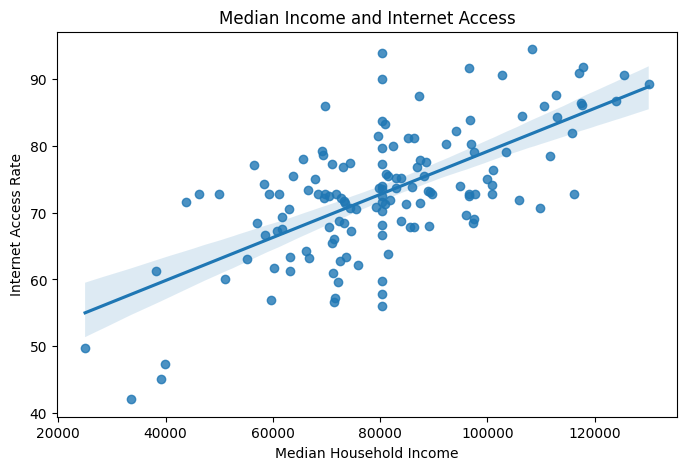

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(data=nj_data, x="median_income", y="internet_access_rate", ci=95)
plt.title("Median Income and Internet Access")
plt.xlabel("Median Household Income")
plt.ylabel("Internet Access Rate")
plt.show()

### Reflection Prompt

Before running the model, write your expectation:

- Do you expect income to be positively or negatively associated with internet access?
- Why?

In [ ]:
# Student notes:
# My expectation before running the regression:

## What is Regression?

Regression is a method for estimating the relationship between one outcome variable and one or more predictor variables.

The simple form is:

> **Y = a + bX + ε**

- **Y** is the outcome we want to explain — here, internet access rate.
- **X** is the predictor we think is associated with it — here, median income.
- **a** (the intercept) is the estimated value of Y when X equals zero.
- **b** (the coefficient) tells us how much Y changes, on average, for each one-unit increase in X.
- **ε** (epsilon) is the error term — the part the model cannot explain.

The model does not prove that X *causes* Y. It estimates the strength and direction of their association.

## 3. Run a Simple Linear Regression

The model is:

`internet_access_rate = intercept + beta_1 * median_income + error`

### What to look for in the output

The summary table contains a lot of numbers. Focus on four:

| Output | What it tells you |
|---|---|
| **Coefficient (coef)** | How much the outcome changes per unit increase in the predictor |
| **P-value (P>\|t\|)** | Whether the result is likely to be a real signal. Values below 0.05 are conventional thresholds |
| **R-squared** | The proportion of variation in the outcome explained by the model. 0 = nothing explained; 1 = perfectly explained |
| **Confidence interval [0.025, 0.975]** | The range of plausible values for the coefficient. A range that does not cross zero supports a real association |

The goal is not to memorise these. The goal is to be able to read them in a report.

In [ ]:
model_data = nj_data[["internet_access_rate", "median_income"]].dropna()

X = model_data[["median_income"]]
y = model_data["internet_access_rate"]

X = sm.add_constant(X)

simple_model = sm.OLS(y, X).fit()

print(simple_model.summary())

                             OLS Regression Results                             
Dep. Variable:     internet_access_rate   R-squared:                       0.432
Model:                              OLS   Adj. R-squared:                  0.428
Method:                   Least Squares   F-statistic:                     105.1
Date:                  Thu, 21 May 2026   Prob (F-statistic):           1.09e-18
Time:                          02:58:16   Log-Likelihood:                -473.87
No. Observations:                   140   AIC:                             951.7
Df Residuals:                       138   BIC:                             957.6
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            46.9748  

## 4. Interpret the Coefficient

Focus on the coefficient for `median_income`.

Because income is measured in dollars, a one-dollar increase is too small to interpret. We can rescale income in thousands of dollars.

### What about the confidence interval?

The output shows `[0.025, 0.975]` columns. These are the **95% confidence interval** for the coefficient.

For `income_thousands`, the interval runs approximately from **0.26 to 0.38**.

This means: if we ran this analysis many times on similar data, we would expect the true coefficient to fall within that range 95% of the time. Crucially, this interval does not cross zero — which supports the conclusion that the association is real, not just noise.

In [ ]:
model_data = model_data.copy()
model_data["income_thousands"] = model_data["median_income"] / 1000

X = model_data[["income_thousands"]]
y = model_data["internet_access_rate"]

X = sm.add_constant(X)

income_model = sm.OLS(y, X).fit()

print(income_model.summary())

                             OLS Regression Results                             
Dep. Variable:     internet_access_rate   R-squared:                       0.432
Model:                              OLS   Adj. R-squared:                  0.428
Method:                   Least Squares   F-statistic:                     105.1
Date:                  Thu, 21 May 2026   Prob (F-statistic):           1.09e-18
Time:                          02:58:16   Log-Likelihood:                -473.87
No. Observations:                   140   AIC:                             951.7
Df Residuals:                       138   BIC:                             957.6
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               

In [ ]:
coef = income_model.params["income_thousands"]
pval = income_model.pvalues["income_thousands"]
r2 = income_model.rsquared

print(f"Coefficient for income_thousands: {coef:.3f}")
print(f"P-value: {pval:.4f}")
print(f"R-squared: {r2:.3f}")

print("\nPlain-language interpretation:")
print(f"For every $1,000 increase in median household income, the model estimates a {coef:.2f} percentage-point change in internet access rate, on average.")

Coefficient for income_thousands: 0.321
P-value: 0.0000
R-squared: 0.432

Plain-language interpretation:
For every $1,000 increase in median household income, the model estimates a 0.32 percentage-point change in internet access rate, on average.


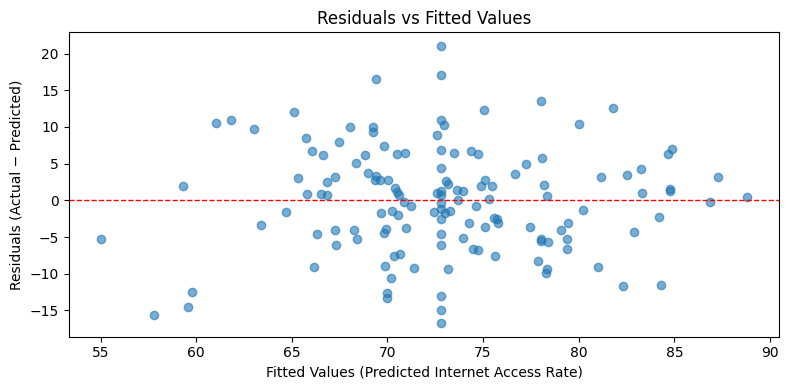

If the residuals appear randomly scattered around zero, the model assumptions are reasonably met.
Clear patterns in the residuals suggest the model is missing something.


In [ ]:
# ============================================================
# CHECK MODEL RESIDUALS
# ============================================================
fitted = income_model.fittedvalues
residuals = income_model.resid

plt.figure(figsize=(8, 4))
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, color="red", linewidth=1, linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values (Predicted Internet Access Rate)")
plt.ylabel("Residuals (Actual − Predicted)")
plt.tight_layout()
plt.show()

print("If the residuals appear randomly scattered around zero, the model assumptions are reasonably met.")
print("Clear patterns in the residuals suggest the model is missing something.")

## 5. Add Additional Variables

If available, we can expand the model to include education and poverty indicators.

In [ ]:
# Ensure income_thousands exists in the main data used for modeling
model_data_multi = nj_data.copy()
model_data_multi["income_thousands"] = model_data_multi["median_income"] / 1000

candidate_predictors = ["income_thousands", "bachelor_degree_rate", "poverty_rate"]
available_predictors = [c for c in candidate_predictors if c in model_data_multi.columns]

model_data_multi = model_data_multi[["internet_access_rate"] + available_predictors].dropna()

if len(available_predictors) >= 2:
    X_multi = model_data_multi[available_predictors]
    y_multi = model_data_multi["internet_access_rate"]
    X_multi = sm.add_constant(X_multi)

    multi_model = sm.OLS(y_multi, X_multi).fit()
    print(multi_model.summary())
else:
    print("Not enough additional variables available for multiple regression.")
    print("Available predictors:", available_predictors)

                             OLS Regression Results                             
Dep. Variable:     internet_access_rate   R-squared:                       0.572
Model:                              OLS   Adj. R-squared:                  0.563
Method:                   Least Squares   F-statistic:                     60.64
Date:                  Thu, 21 May 2026   Prob (F-statistic):           5.96e-25
Time:                          02:58:16   Log-Likelihood:                -454.08
No. Observations:                   140   AIC:                             916.2
Df Residuals:                       136   BIC:                             927.9
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

## 6. Compare Simple and Multiple Models

If a multiple regression model was created, compare:

- Did the income coefficient change?
- Did model fit improve?
- Are the results easier or harder to explain?

In [ ]:
try:
    comparison = pd.DataFrame({
        "Model": ["Simple income model", "Multiple predictor model"],
        "R_squared": [income_model.rsquared, multi_model.rsquared],
        "Adjusted_R_squared": [income_model.rsquared_adj, multi_model.rsquared_adj]
    })
    display(comparison)
except NameError:
    print("Multiple model not available. Run the previous cell if additional predictors exist.")

,Model,R_squared,Adjusted_R_squared
0,Simple income model,0.432415,0.428302
1,Multiple predictor model,0.572214,0.562778


## 7. Interpret Results for Decision Making ⏱ 10 min

Use the model output to complete the following interpretation framework. Write your answers in the code cell below.

> **Finding:** The model suggests that...  
> **Meaning:** In practical terms, this may indicate that...  
> **Limitation:** This model does not prove causation because...  
> **Implication:** Decision-makers could use this information to...

In [ ]:
# YOUR INTERPRETATION
# Replace each placeholder with your own sentences.

finding     = "[The model suggests that...]"
meaning     = "[In practical terms, this may indicate that...]"
limitation  = "[This model does not prove causation because...]"
implication = "[Decision-makers could use this information to...]"

print("Finding:    ", finding)
print("Meaning:    ", meaning)
print("Limitation: ", limitation)
print("Implication:", implication)

Finding:     [The model suggests that...]
Meaning:     [In practical terms, this may indicate that...]
Limitation:  [This model does not prove causation because...]
Implication: [Decision-makers could use this information to...]


## 8. Discuss Limitations

Regression is useful, but it is not magic.

Important limitations:

- Association does not prove causation.
- Missing variables may affect results.
- Data quality matters.
- Geographic patterns may require spatial analysis.
- One model cannot fully explain complex inequality.

## 9. Exit Ticket ⏱ 5 min

Before you finish, write a brief answer to each question.

1. **What did the regression model suggest about income and internet access?**

2. **What is one limitation of this model that you would flag to a decision-maker?**

3. **What additional variable would you add to the next version of this model, and why?**

In [ ]:
# EXIT TICKET — type your answers here if preferred

q1_model_finding     = ""
q2_limitation        = ""
q3_additional_variable = ""

## Suggested Extension

After the workshop, participants can:

- Add more predictors.
- Test a different outcome variable.
- Improve the regression visualization.
- Write a 150-word interpretation of the findings for a non-technical audience.

---

## Learning Objectives — Check-In

At the start of this workshop, we set four goals.

1. ✅ Explain what regression is used for.
2. ✅ Run a simple regression model in Python.
3. ✅ Interpret coefficients in plain language.
4. ✅ Discuss limitations and real-world implications.

If any of these feel uncertain, the Suggested Extension section gives you ways to continue exploring before the next workshop.